In [1]:
install.packages("ggplot2")

install.packages("dplyr")

install.packages("readr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(ggplot2)

library(dplyr)

library(readr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
unzip("/content/northstar_dataset.zip",
      exdir="/content/northstar_data")

print("Dataset Extracted Successfully")

[1] "Dataset Extracted Successfully"


In [4]:
deliveries <- read_csv(
"/content/northstar_data/northstar_dataset/deliveries.csv"
)

complaints <- read_csv(
"/content/northstar_data/northstar_dataset/complaints.csv"
)

orders <- read_csv(
"/content/northstar_data/northstar_dataset/orders.csv"
)

drivers <- read_csv(
"/content/northstar_data/northstar_dataset/drivers.csv"
)

Rows: 950 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): delivery_id, order_id, driver_id, vehicle_id, hub_id, delivery_status
dbl  (5): route_distance_km, manual_route_override_count, proof_of_completio...
dttm (2): dispatch_time, delivery_completed_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 320 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): complaint_id, customer_id, order_id, complaint_type, channel, seve...
dbl  (2): resolution_days, compensation_amount
dttm (1): created_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1250 Columns: 11
── Column specification ────────────────────────────────────────────────────

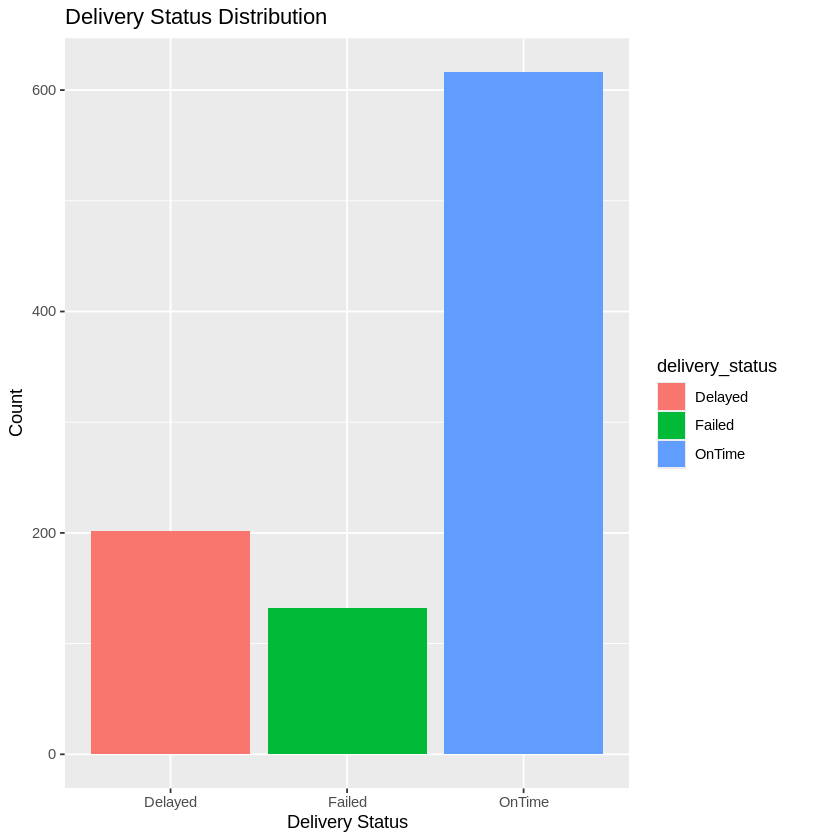

In [5]:
ggplot(deliveries,
aes(x = delivery_status,
fill = delivery_status)) +

geom_bar() +

labs(
title = "Delivery Status Distribution",
x = "Delivery Status",
y = "Count"
)

## Delivery Performance Insight

The visualisation highlights the distribution of delivery outcomes across the organisation. The presence of delayed and failed deliveries indicates operational inefficiencies affecting service reliability. These delivery issues may contribute to increased customer dissatisfaction and financial losses.

Warning message:
“Removed 14 rows containing non-finite outside the scale range (`stat_bin()`).”


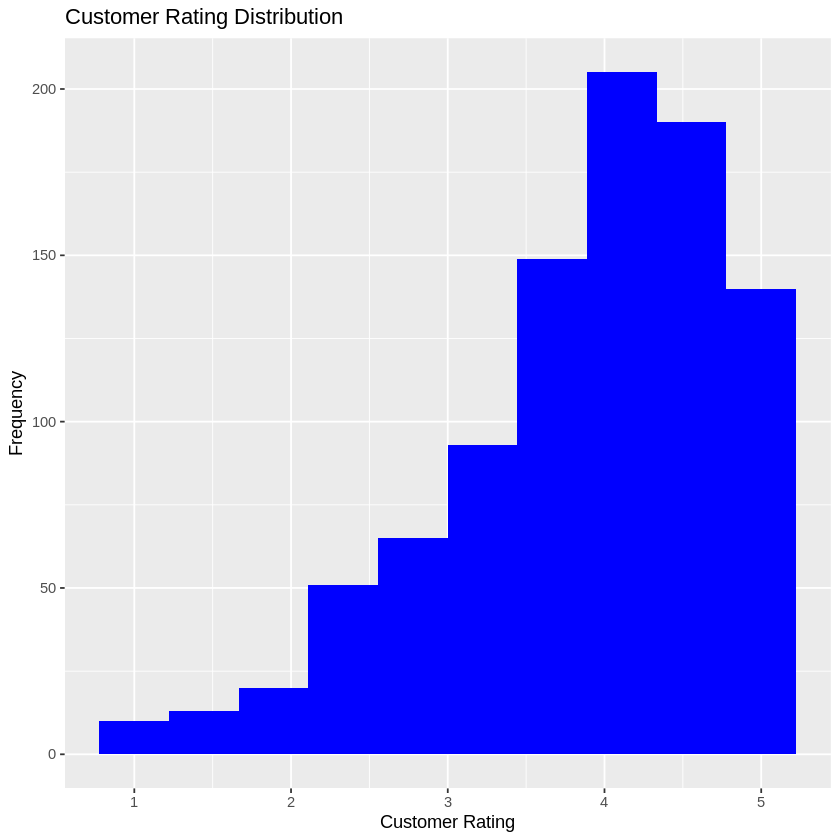

In [6]:
ggplot(deliveries,
aes(x = customer_rating_post_delivery)) +

geom_histogram(bins = 10,
fill = "blue") +

labs(
title = "Customer Rating Distribution",
x = "Customer Rating",
y = "Frequency"
)

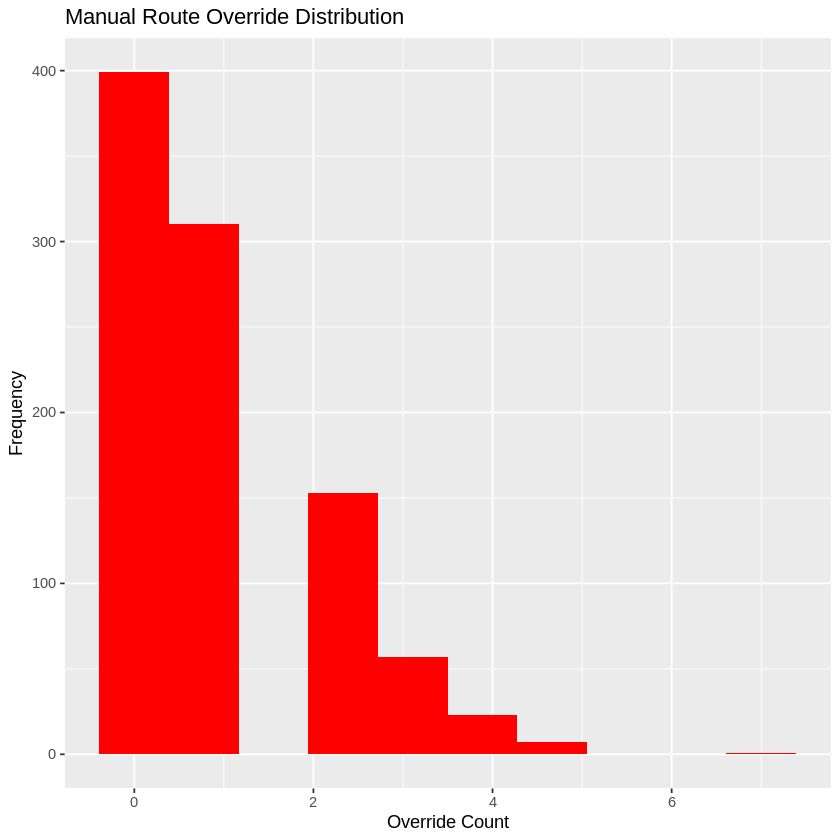

In [7]:
ggplot(deliveries,
aes(x = manual_route_override_count)) +

geom_histogram(bins = 10,
fill = "red") +

labs(
title = "Manual Route Override Distribution",
x = "Override Count",
y = "Frequency"
)

## Route Override Insight

The analysis shows that manual route overrides occur frequently across deliveries. This may indicate poor route optimisation, traffic disruptions, or operational inefficiencies. Frequent overrides can increase delays, fuel costs, and customer dissatisfaction.

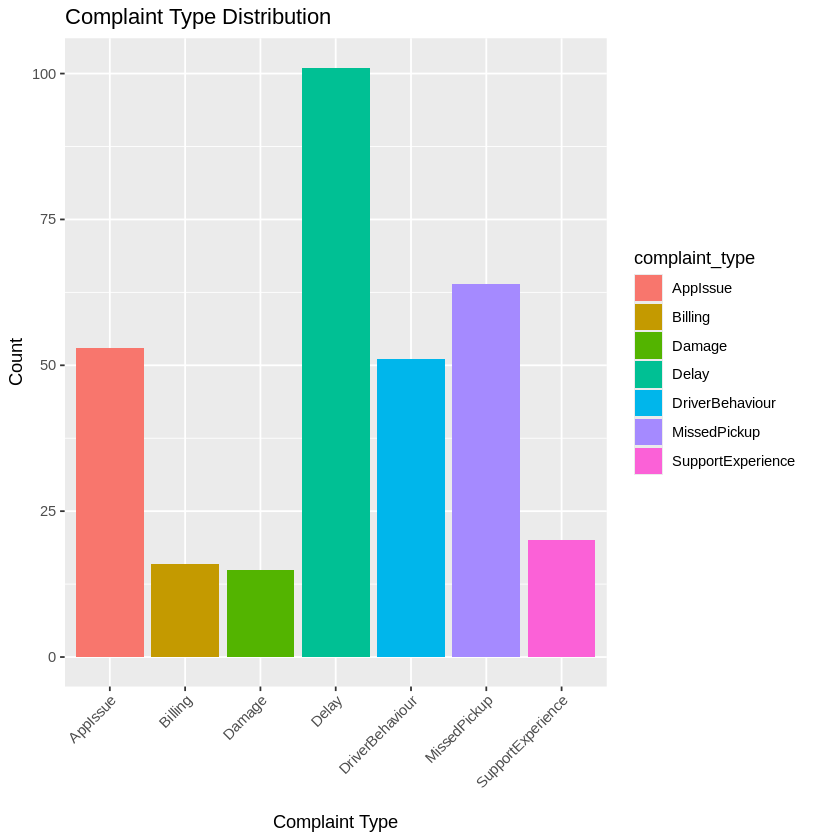

In [8]:
ggplot(complaints,
aes(x = complaint_type,
fill = complaint_type)) +

geom_bar() +

theme(axis.text.x =
element_text(angle = 45, hjust = 1)) +

labs(
title = "Complaint Type Distribution",
x = "Complaint Type",
y = "Count"
)

In [9]:
cor(
deliveries$route_distance_km,
deliveries$fuel_or_charge_cost,
use = "complete.obs"
)

[1] 0.5241945

## Correlation Analysis Insight

The correlation analysis examines the relationship between route distance and fuel or charging costs. A positive correlation indicates that longer delivery routes contribute directly to increased operational costs, affecting profitability and efficiency.

`geom_smooth()` using formula = 'y ~ x'


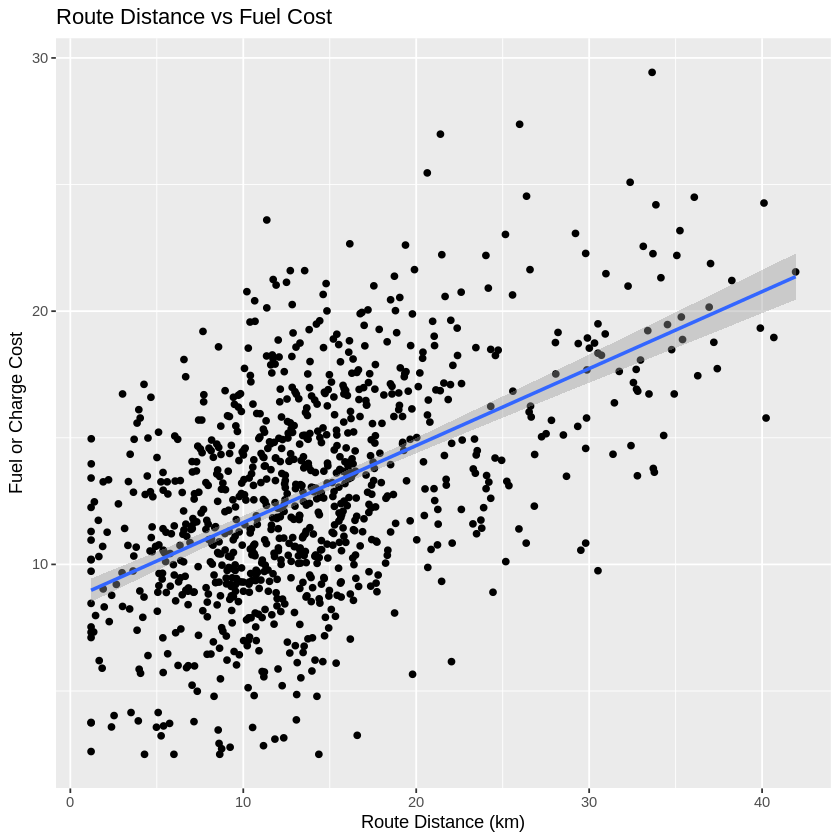

In [10]:
ggplot(deliveries,
aes(
x = route_distance_km,
y = fuel_or_charge_cost
)) +

geom_point() +

geom_smooth(method = "lm") +

labs(
title = "Route Distance vs Fuel Cost",
x = "Route Distance (km)",
y = "Fuel or Charge Cost"
)

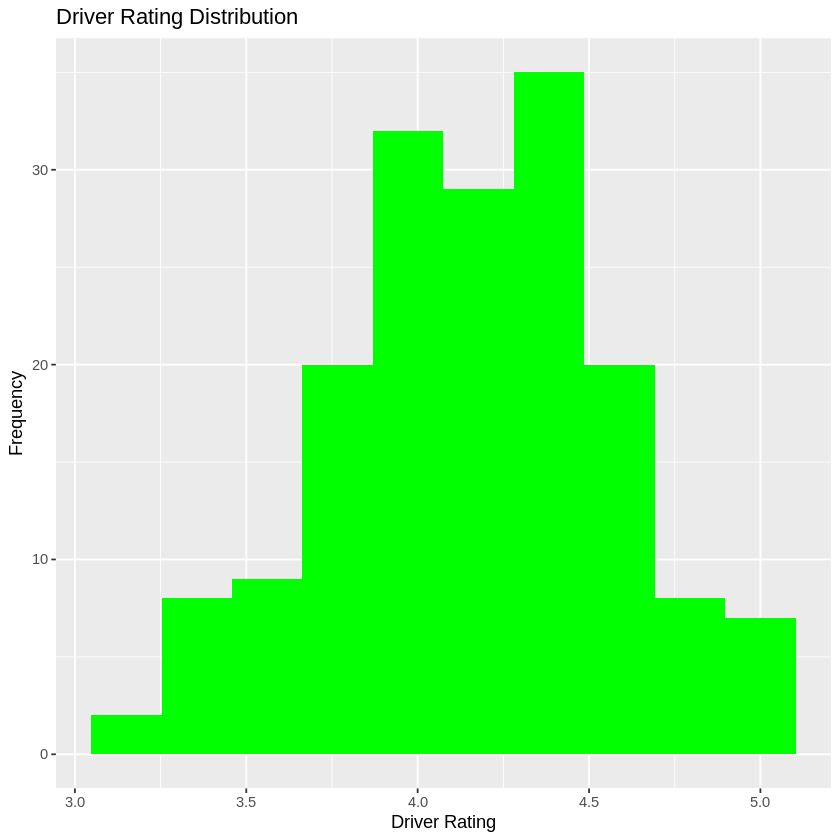

In [11]:
ggplot(drivers,
aes(x = driver_rating)) +

geom_histogram(
bins = 10,
fill = "green"
) +

labs(
title = "Driver Rating Distribution",
x = "Driver Rating",
y = "Frequency"
)